# Resolución del 8-Puzzle mediante Algoritmos de Búsqueda

**Escuela:** Escuela Superior de Cómputo (ESCOM - IPN)
**Materia:** Inteligencia Artificial

**Alumno:** Gustavo Linares Villegas <br>
**Alumno:** Barrera Puente Eric Alejandro <br>
**Alumno:** Barrera Puente Eric Alejandro <br>


*Cuadro 3x3 con 8 fichas sudoku*

## Introducción

El presente proyecto tiene como objetivo aplicar diferentes algoritmos de búsqueda para resolver el problema clásico del **8-Puzzle**, un rompecabezas deslizante compuesto por ocho fichas numeradas y un espacio vacío en un tablero de 3x3.

Este problema es ampliamente utilizado en inteligencia artificial para estudiar técnicas de búsqueda en espacios de estados.

En este proyecto se implementan dos algoritmos:

- **Búsqueda en Anchura (BFS)**
- **Búsqueda A\***

Además se comparará su rendimiento en términos de:

- Tiempo de ejecución
- Número de nodos explorados
- Longitud de la solución

También se implementan herramientas adicionales como:

- Verificación de solvencia del puzzle
- Visualización animada de la solución
- Gráficas de rendimiento

In [25]:
# Anexando imports
from __future__ import annotations

import argparse
import random
import time
import os
from dataclasses import dataclass
from collections import deque
import heapq
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
import matplotlib.pyplot as plt


In [26]:
## ----------------------- | Configuracion del tablero |----------------------- ##

GOAL_STATE: Tuple[int, ...] = (
    1, 2, 3,
    4, 5, 6,
    7, 8, 0
)

MOVES: Dict[str, int] = {
    "UP": -3,
    "DOWN": 3,
    "LEFT": -1,
    "RIGHT": 1
}


@dataclass(frozen=True)
class SolveResult:
    algo: str
    solved: bool
    time_s: float
    nodes_expanded: int
    solution_len: int
    solution_moves: Tuple[str, ...]

## Modelo de resultados

Para almacenar los resultados obtenidos por los algoritmos se utiliza una estructura de datos llamada `SolveResult`.

Esta estructura permite registrar:

- Algoritmo utilizado
- Si se encontró solución
- Tiempo de ejecución
- Número de nodos explorados
- Longitud de la solución

In [27]:
@dataclass(frozen=True)
class SolveResult:
    algo: str
    solved: bool
    time_s: float
    nodes_expanded: int
    solution_len: int
    solution_moves: Tuple[str, ...]

## Funciones auxiliares

Se implementan funciones básicas para manipular el tablero del puzzle.

Estas funciones permiten:

- Mostrar el tablero
- Determinar movimientos posibles
- Aplicar movimientos al estado

In [28]:
def print_board(state: Sequence[int]) -> None:
    for r in range(3):
        row = state[r * 3:(r + 1) * 3]
        print(" ".join(" " if x == 0 else str(x) for x in row))
        

In [29]:
def get_possible_moves(zero_index: int) -> List[str]:
    
    row = zero_index // 3
    col = zero_index % 3

    possible = []

    if row > 0:
        possible.append("UP")
    if row < 2:
        possible.append("DOWN")
    if col > 0:
        possible.append("LEFT")
    if col < 2:
        possible.append("RIGHT")

    return possible

In [30]:
def apply_move(state: Tuple[int, ...], move: str) -> Tuple[int, ...]:

    zero_index = state.index(0)
    target_index = zero_index + MOVES[move]

    new_state = list(state)

    new_state[zero_index], new_state[target_index] = (
        new_state[target_index],
        new_state[zero_index],
    )

    return tuple(new_state)

## Heurística Manhattan

El algoritmo A* utiliza la heurística **distancia Manhattan**.

Esta heurística calcula la distancia entre la posición actual de cada ficha y su posición objetivo.

La fórmula utilizada es:

|x1 − x2| + |y1 − y2|

Esta heurística es **admisible**, lo que significa que nunca sobreestima el costo real.

In [31]:
def manhattan_distance(state: Tuple[int, ...]) -> int:

    goal_pos = {value: idx for idx, value in enumerate(GOAL_STATE)}

    dist = 0

    for i, value in enumerate(state):

        if value == 0:
            continue

        gi = goal_pos[value]

        x1, y1 = divmod(i, 3)
        x2, y2 = divmod(gi, 3)

        dist += abs(x1 - x2) + abs(y1 - y2)

    return dist

## Verificación de solvencia

No todos los estados del 8-Puzzle pueden resolverse.

Para determinar si un puzzle es resoluble se calcula el **número de inversiones**.

Una inversión ocurre cuando una ficha mayor aparece antes que una ficha menor.

Para tableros de tamaño impar (3x3), el puzzle es resoluble cuando el número de inversiones es **par**.

In [32]:
def inversion_count(state: Sequence[int]) -> int:

    arr = [x for x in state if x != 0]

    inv = 0

    for i in range(len(arr)):
        for j in range(i + 1, len(arr)):
            if arr[i] > arr[j]:
                inv += 1

    return inv

In [33]:
def is_solvable_3x3(state: Sequence[int]) -> bool:
    return inversion_count(state) % 2 == 0

## Algoritmo BFS (Breadth First Search)

BFS explora el espacio de estados **nivel por nivel**.

Características:

- Garantiza encontrar la solución óptima
- Explora muchos nodos
- Puede consumir gran cantidad de memoria

In [34]:
def bfs(start_state: Tuple[int, ...]) -> SolveResult:

    t0 = time.perf_counter()

    q = deque([(start_state, ())])

    visited = set()

    nodes = 0

    while q:

        state, path = q.popleft()

        if state in visited:
            continue

        visited.add(state)

        nodes += 1

        if state == GOAL_STATE:

            return SolveResult("BFS", True, time.perf_counter() - t0, nodes, len(path), path)

        z = state.index(0)

        for mv in get_possible_moves(z):

            nxt = apply_move(state, mv)

            if nxt not in visited:

                q.append((nxt, path + (mv,)))

    return SolveResult("BFS", False, time.perf_counter() - t0, nodes, 0, ())

## Algoritmo A*

El algoritmo A* utiliza una función de evaluación:

f(n) = g(n) + h(n)

donde:

g(n) = costo acumulado  
h(n) = heurística (distancia Manhattan)

Esto permite explorar primero los estados más prometedores.

In [35]:
def a_star(start_state: Tuple[int, ...]) -> SolveResult:

    t0 = time.perf_counter()

    heap = []

    heapq.heappush(heap, (manhattan_distance(start_state), 0, start_state, ()))

    visited = set()

    nodes = 0

    while heap:

        f, g, state, path = heapq.heappop(heap)

        if state in visited:
            continue

        visited.add(state)

        nodes += 1

        if state == GOAL_STATE:

            return SolveResult("A*", True, time.perf_counter() - t0, nodes, len(path), path)

        z = state.index(0)

        for mv in get_possible_moves(z):

            nxt = apply_move(state, mv)

            if nxt in visited:
                continue

            ng = g + 1

            nf = ng + manhattan_distance(nxt)

            heapq.heappush(heap, (nf, ng, nxt, path + (mv,)))

    return SolveResult("A*", False, time.perf_counter() - t0, nodes, 0, ())

## Generación de instancias

Para evaluar los algoritmos se generan puzzles aleatorios aplicando movimientos desde el estado objetivo.

Esto garantiza que los estados generados sean **resolubles**.

In [36]:
def scramble_from_goal(steps: int) -> Tuple[int, ...]:

    state = GOAL_STATE

    for _ in range(steps):

        z = state.index(0)

        moves = get_possible_moves(z)

        mv = random.choice(moves)

        state = apply_move(state, mv)

    return state

## Ejecución de los algoritmos

In [37]:
initial_state = scramble_from_goal(20)

print("Estado inicial")

print_board(initial_state)

Estado inicial
1 5 2
4   3
7 8 6


In [38]:
result_bfs = bfs(initial_state)

result_astar = a_star(initial_state)

print(result_bfs)

print(result_astar)

SolveResult(algo='BFS', solved=True, time_s=0.00016130000017255952, nodes_expanded=24, solution_len=4, solution_moves=('UP', 'RIGHT', 'DOWN', 'DOWN'))
SolveResult(algo='A*', solved=True, time_s=0.00036240000008547213, nodes_expanded=5, solution_len=4, solution_moves=('UP', 'RIGHT', 'DOWN', 'DOWN'))


## Comparación de rendimiento

In [39]:
algorithms = ["BFS", "A*"]

times = [result_bfs.time_s, result_astar.time_s]

nodes = [result_bfs.nodes_expanded, result_astar.nodes_expanded]

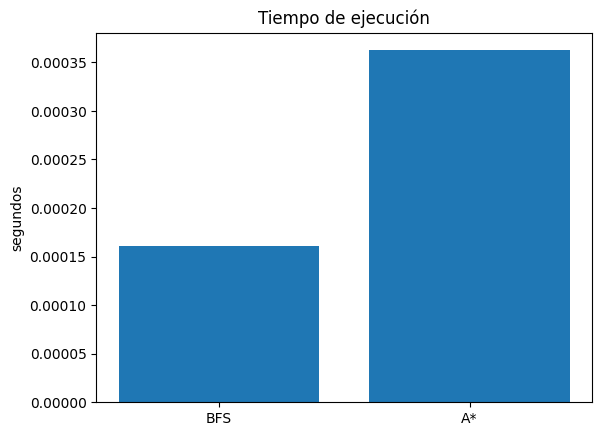

In [40]:
plt.bar(algorithms, times)

plt.title("Tiempo de ejecución")

plt.ylabel("segundos")

plt.show()

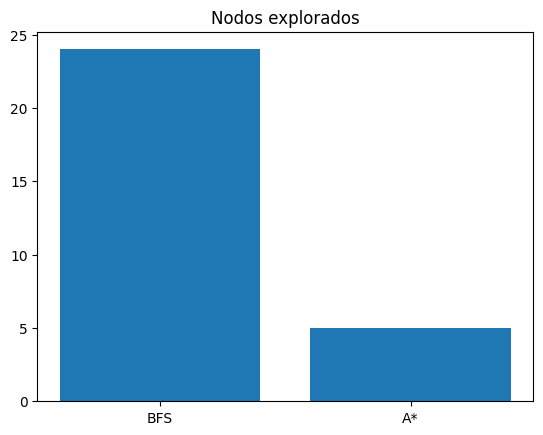

In [41]:
plt.bar(algorithms, nodes)

plt.title("Nodos explorados")

plt.show()

## Visualización de la solución

In [42]:
def animate_solution(start, moves):

    state = start

    print_board(state)

    for mv in moves:

        time.sleep(0.5)

        state = apply_move(state, mv)

        print("Movimiento:", mv)

        print_board(state)

In [43]:
animate_solution(initial_state, result_astar.solution_moves)

1 5 2
4   3
7 8 6
Movimiento: UP
1   2
4 5 3
7 8 6
Movimiento: RIGHT
1 2  
4 5 3
7 8 6
Movimiento: DOWN
1 2 3
4 5  
7 8 6
Movimiento: DOWN
1 2 3
4 5 6
7 8  
